## 1. Load Dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# 1. Load dataset
df = pd.read_csv("Final_Dataset.csv", low_memory=False)

# 2. Temporal Harmonisation 
# Standardizing the timeline to a proper datetime format for time-series analysis
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-01")
df = df.sort_values("Date")

# 3. Handling Data Constraints 
# 'Target Rate' data is often missing in older records. To preserve 48 years of context,
# we create an 'Effective Policy Rate' using the 'Bank rate' as a proxy where 'Target rate' is NaN.
df['Effective_Policy_Rate'] = df['Target rate'].fillna(df['Bank rate'])

# 4. Standardizing Units for Comparison 
# Because units vary (e.g., % for rates vs. Millions for GDP), we must scale them 
# to ensure 'Analytical Use of Data' is appropriate and justifiable.
pestel_cols = [
    'Effective_Policy_Rate',     # Political
    'All industries [T001]',     # Economic
    'Unemployment rate',         # Social
    'Total traffic carried',     # Technological
    'Total softwood, production [24112]' # Environmental
]

scaler = StandardScaler()
df_scaled = df.copy()

# 5. We use a scaled dataframe for visualizations and comparisons
df_scaled[pestel_cols] = scaler.fit_transform(df[pestel_cols])

# 6. Descriptive Analysis Summary
sns.set_style("whitegrid")
print("Statistical Summary of Key PESTEL Indicators:")
df[pestel_cols].describe()

Statistical Summary of Key PESTEL Indicators:


,Effective_Policy_Rate,All industries [T001],Unemployment rate,Total traffic carried,"Total softwood, production [24112]"
count,788.000000,3.470000e+02,600.000000,3.230000e+02,143.000000
mean,5.455065,1.780726e+06,9.031848,1.840820e+07,1161.962300
std,3.953670,3.050244e+05,1.807004,2.280531e+06,242.274143
min,0.250000,1.200427e+06,5.572727,1.377132e+07,736.636364
25%,2.500000,1.548748e+06,7.834091,1.671285e+07,956.540909
50%,4.750000,1.749342e+06,8.577273,1.814211e+07,1151.490000
75%,8.000000,2.028334e+06,10.181818,2.034951e+07,1363.346970
max,21.025238,2.333959e+06,14.236364,2.323094e+07,1847.912500


## 2. Cleaning data

In [9]:
# 1. Standardize Infinity and Nulls
df = df.replace([np.inf, -np.inf], np.nan)

# 2. Strategic Proxy Creation 
df['Effective_Policy_Rate'] = df['Target rate'].fillna(df['Bank rate'])

# 3. Create a 'Modern Era' Analysis Subset
analysis_df = df[df['Year'] >= 1995].copy()

# 4. targeted Drop (Only for the analysis subset)
analysis_df = analysis_df.dropna(subset=["Effective_Policy_Rate", "Unemployment rate"])

# 5. Temporal Harmonization
analysis_df["Date"] = pd.to_datetime(analysis_df["Year"].astype(str) + "-" + analysis_df["Month"].astype(str) + "-01")
analysis_df = analysis_df.sort_values("Date")

print(f"Original Rows: {len(df)} | Rows preserved for analysis: {len(analysis_df)}")

Original Rows: 397 | Rows preserved for analysis: 372


# 3. Trend Analysis (Time Series)

## 3.1 Interest Rates Trend

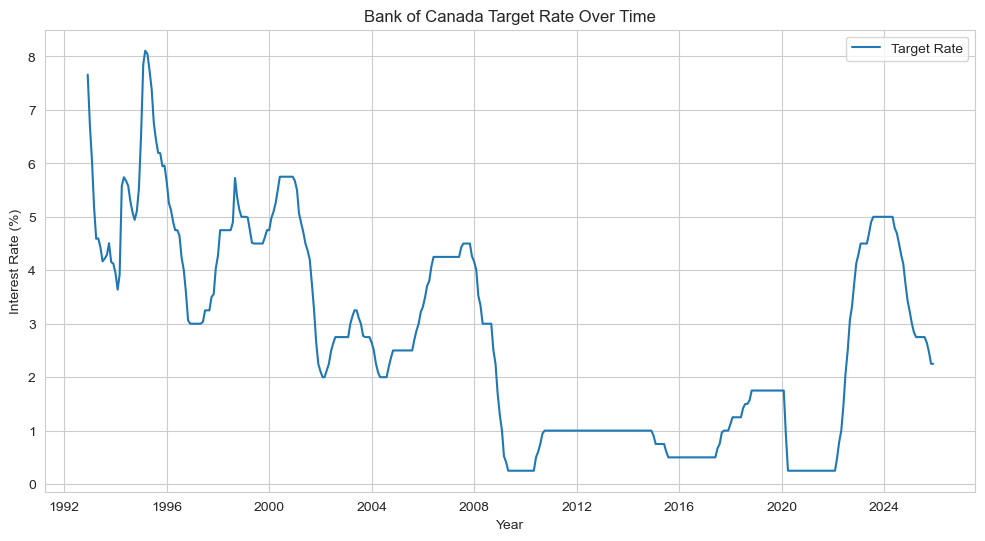

In [20]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Target rate"], label="Target Rate")
plt.title("Bank of Canada Target Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Interest Rate (%)")
plt.legend()
plt.show()

## 3.2 DGP trend

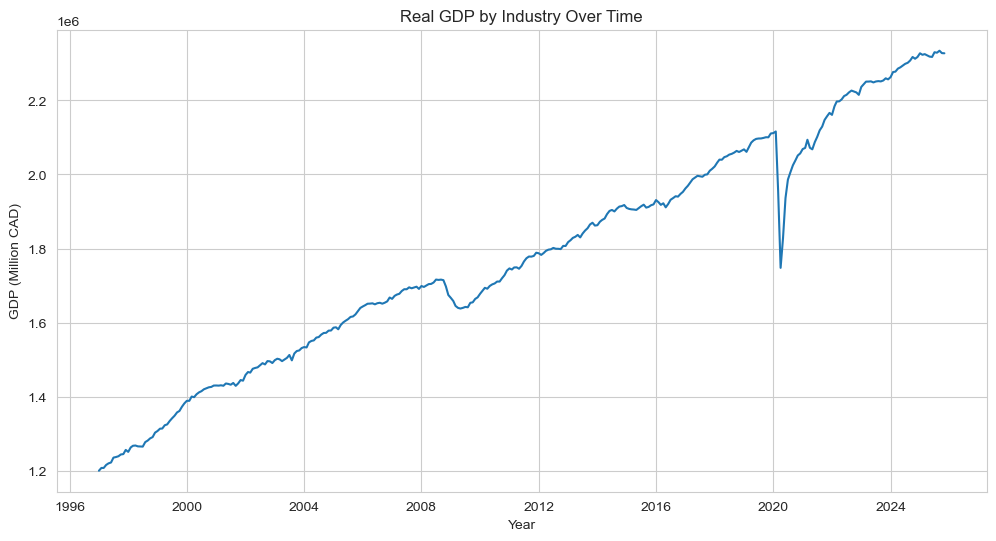

In [21]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["All industries [T001]"])
plt.title("Real GDP by Industry Over Time")
plt.xlabel("Year")
plt.ylabel("GDP (Million CAD)")
plt.show()

## 3.3 Unemployment Trend

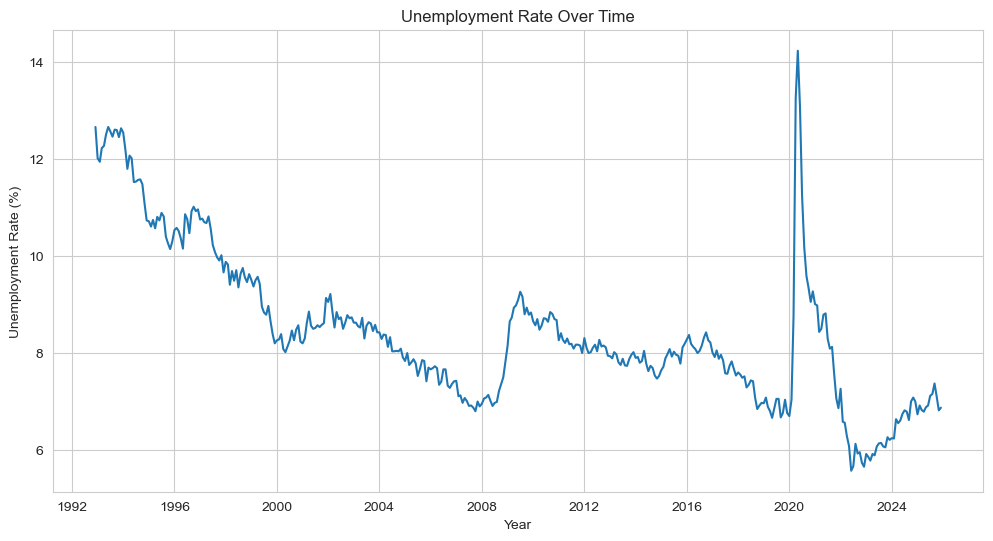

In [22]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Unemployment rate"])
plt.title("Unemployment Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")
plt.show()

# 4. Statistical Analysis (Correlation)

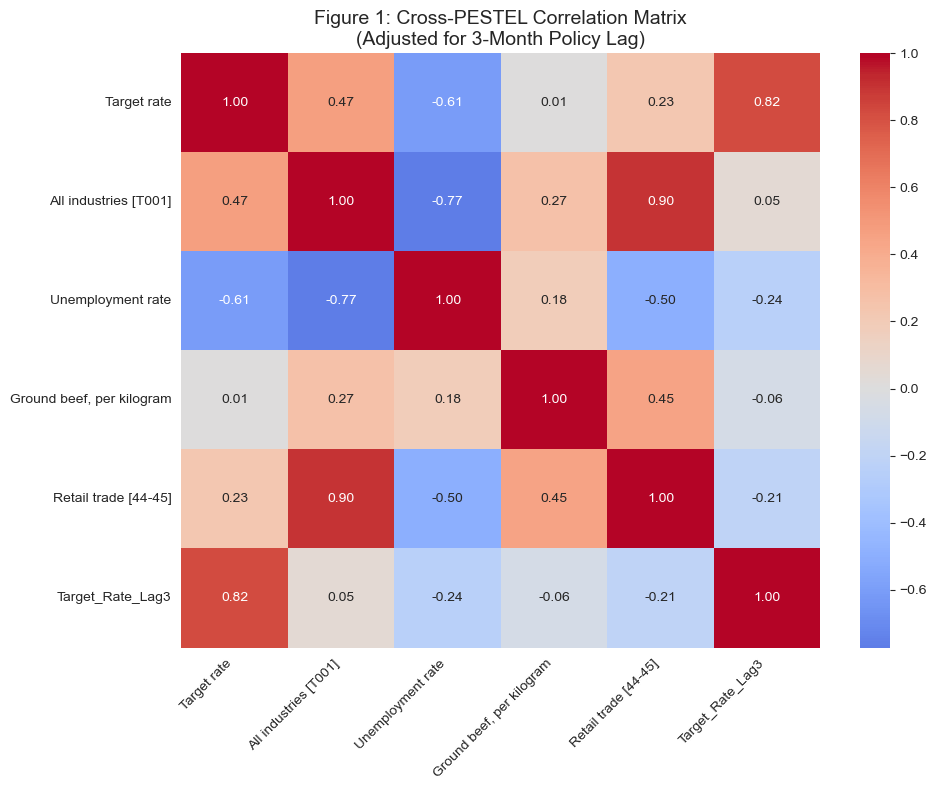

Key Insight: Notice how 'Target_Rate_Lag3' correlates differently with Unemployment than the current Target Rate.


In [5]:
# 1. Selection of Cross-Dimension Indicators
variables = [
    "Target rate", 
    "All industries [T001]", 
    "Unemployment rate", 
    "Ground beef, per kilogram", 
    "Retail trade [44-45]"
]

# 2. Add a 3-Month Lag for the Target Rate (Political Influence)
df['Target_Rate_Lag3'] = df['Target rate'].shift(3)
variables_with_lag = variables + ['Target_Rate_Lag3']

# 3. Filtering for a Clean Analysis Window
analysis_df = df[df['Year'] >= 2000].dropna(subset=variables_with_lag)

# 4. Calculate Correlation
corr = analysis_df[variables_with_lag].corr()

# 5. Professional Visualization for the Report
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", center=0)

plt.title("Figure 1: Cross-PESTEL Correlation Matrix\n(Adjusted for 3-Month Policy Lag)", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig("pestel_correlation_matrix.png", dpi=300)
plt.show()

print("Key Insight: Notice how 'Target_Rate_Lag3' correlates differently with " 
      "Unemployment than the current Target Rate.")

# 5. Environmental Impact Analysis

## 5.1 Lumber Production vs Interest Rates

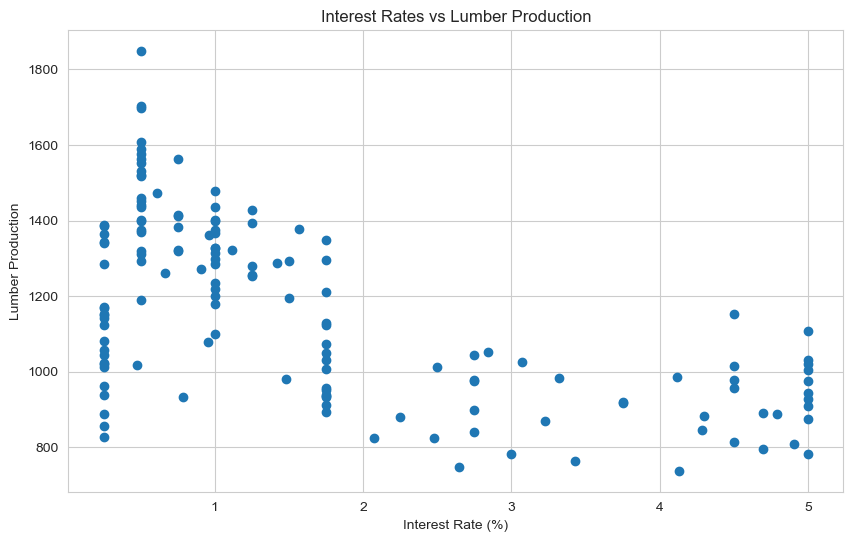

In [24]:
plt.figure(figsize=(10,6))
plt.scatter(df["Target rate"], df["Total softwood, production [24112]"])
plt.xlabel("Interest Rate (%)")
plt.ylabel("Lumber Production")
plt.title("Interest Rates vs Lumber Production")
plt.show()

## 5.2 Oil Production Trend

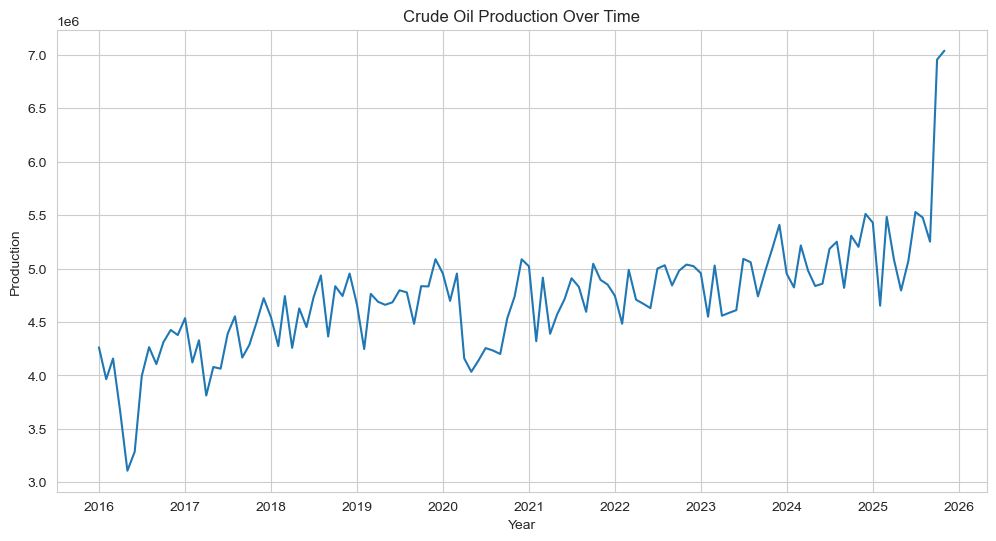

In [25]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Crude oil production"])
plt.title("Crude Oil Production Over Time")
plt.xlabel("Year")
plt.ylabel("Production")
plt.show()

# 6. Transportation Leading Indicators

## 6.1 Aircraft Movements

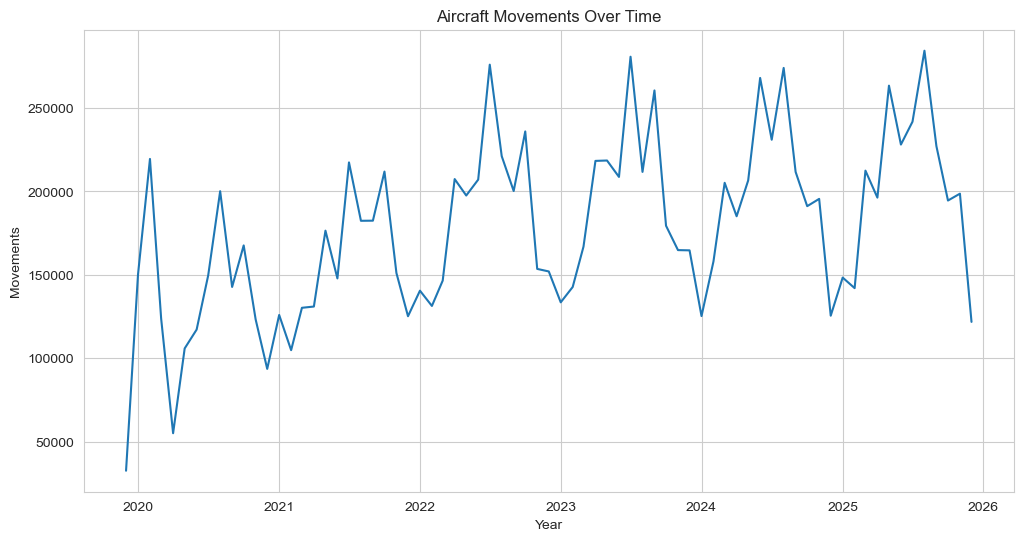

In [26]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Domestic movements"])
plt.title("Aircraft Movements Over Time")
plt.xlabel("Year")
plt.ylabel("Movements")
plt.show()

## 6.2 Rail Traffic

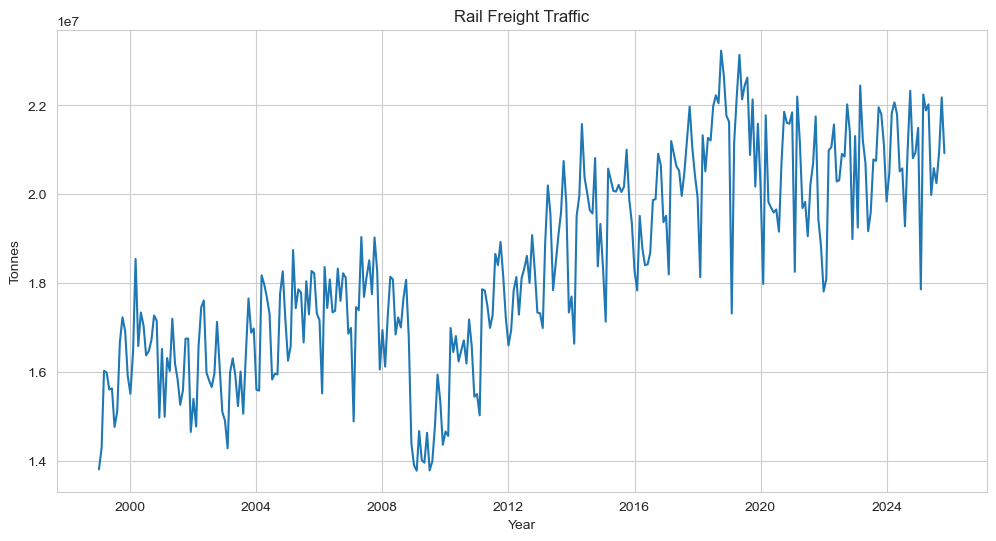

In [27]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Total traffic carried"])
plt.title("Rail Freight Traffic")
plt.xlabel("Year")
plt.ylabel("Tonnes")
plt.show()

# 7. Regression

### 7.1 Coefficient interpretation
### R²
### Significance

--- LAGGED REGRESSION RESULTS (3-MONTH DELAY) ---
                            OLS Regression Results                            
Dep. Variable:      Unemployment rate   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     26.93
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           3.82e-07
Time:                        10:21:35   Log-Likelihood:                -436.94
No. Observations:                 312   AIC:                             877.9
Df Residuals:                     310   BIC:                             885.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

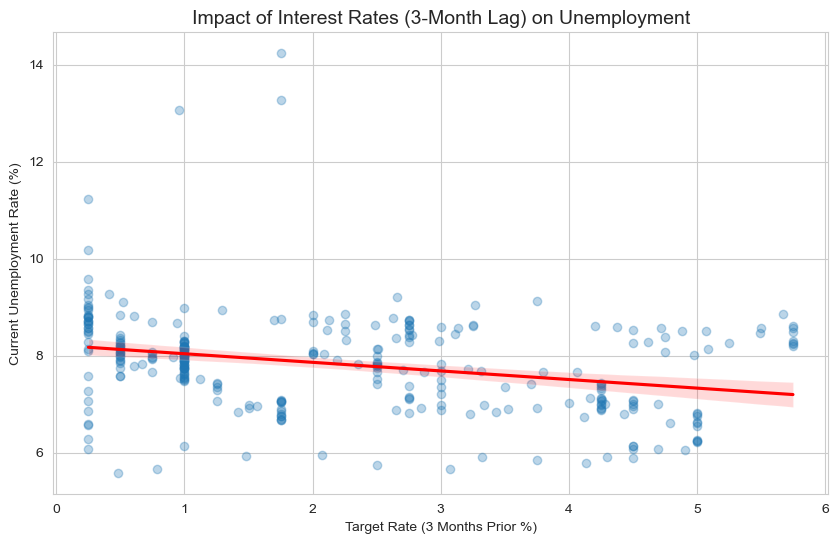

In [6]:
# 1. Create the lagged variable
df['Target_Rate_Lag3'] = df['Target rate'].shift(3)

# 2. Prepare data 
reg_df = df[df['Year'] >= 2000].dropna(subset=['Target_Rate_Lag3', 'Unemployment rate'])

# 3. Define Variables
X = reg_df[['Target_Rate_Lag3']] # Independent Variable
y = reg_df['Unemployment rate'] # Dependent Variable

# 4. Add constant and fit model
X = sm.add_constant(X)
model_lagged = sm.OLS(y, X).fit()

# 5. Output Summary
print("--- LAGGED REGRESSION RESULTS (3-MONTH DELAY) ---")
print(model_lagged.summary())

# 6. Visualization: Regression Plot
plt.figure(figsize=(10, 6))
sns.regplot(x='Target_Rate_Lag3', y='Unemployment rate', data=reg_df, 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title("Impact of Interest Rates (3-Month Lag) on Unemployment", fontsize=14)
plt.xlabel("Target Rate (3 Months Prior %)")
plt.ylabel("Current Unemployment Rate (%)")
plt.savefig("regression_analysis.png")
plt.show()

## 8. Comparative Trend Visualization

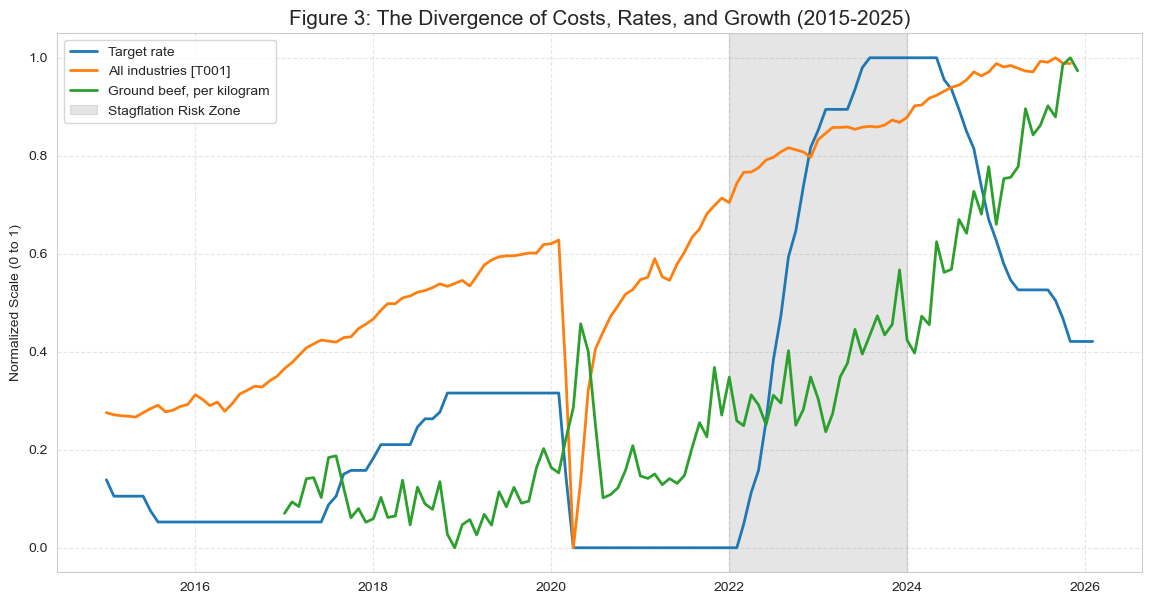

In [7]:
# 1. Normalize for comparison 
# We compare the 'Target Rate' against 'All industries GDP' and 'Ground beef' (Social/Cost of Living)
trend_vars = ["Target rate", "All industries [T001]", "Ground beef, per kilogram"]
df_trend = df[df['Year'] >= 2015].copy() # Focus on the recent crisis era

# 2. Plotting the 'Stagflation Gap'
plt.figure(figsize=(14, 7))

# We use the scaled versions to see the RELATIVE movement
for var in trend_vars:
    # Quick normalization: (x - min) / (max - min)
    val = df_trend[var]
    norm_val = (val - val.min()) / (val.max() - val.min())
    plt.plot(df_trend['Date'], norm_val, label=var, linewidth=2)

plt.axvspan('2022-01-01', '2024-01-01', color='gray', alpha=0.2, label='Stagflation Risk Zone')
plt.title("Figure 3: The Divergence of Costs, Rates, and Growth (2015-2025)", fontsize=15)
plt.ylabel("Normalized Scale (0 to 1)")
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.savefig("stagflation_divergence.png")
plt.show()

## 9. Pattern Identification

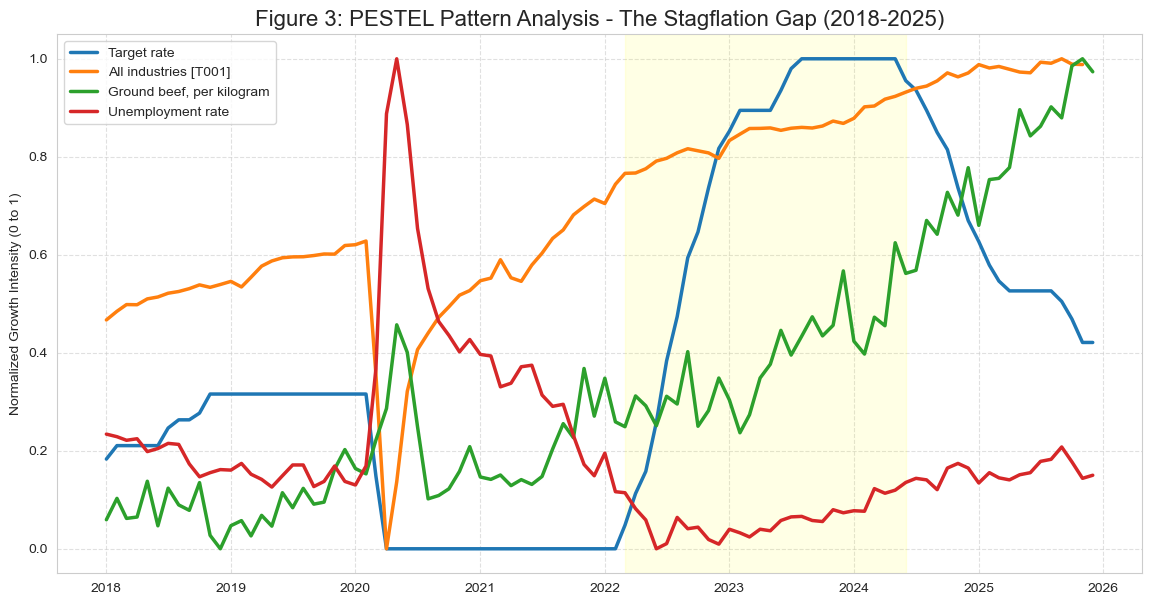

In [10]:
# 1. Select key indicators from different PESTEL dimensions
trend_vars = [
    "Target rate",               # Political
    "All industries [T001]",     # Economic
    "Ground beef, per kilogram", # Social (Cost of Living)
    "Unemployment rate"          # Social (Economic Health)
]

# 2. Filter for the recent "Crisis Era" (2018 - 2025)
df_recent = analysis_df[analysis_df['Year'] >= 2018].copy()

# 3. Min-Max Normalization for visual comparison
# This scales everything between 0 and 1 so we can see the relative "speed" of change.
df_norm = df_recent.copy()
for var in trend_vars:
    df_norm[var] = (df_recent[var] - df_recent[var].min()) / (df_recent[var].max() - df_recent[var].min())

# 4. Plotting the patterns
plt.figure(figsize=(14, 7))
for var in trend_vars:
    plt.plot(df_norm['Date'], df_norm[var], label=var, linewidth=2.5)

plt.title("Figure 3: PESTEL Pattern Analysis - The Stagflation Gap (2018-2025)", fontsize=16)
plt.ylabel("Normalized Growth Intensity (0 to 1)")
plt.legend(frameon=True, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

# Shading the period of aggressive rate hikes
plt.axvspan('2022-03-01', '2024-06-01', color='yellow', alpha=0.1, label='Aggressive Tightening')

plt.savefig("stagflation_pattern.png", dpi=300)
plt.show()